# Laboratorio 5: Clasificación de tweets sobre desastres

## Objetivo

El objetivo de este laboratorio es aplicar técnicas de minería de texto para analizar y clasificar tweets. Se busca construir un modelo que determine si un tweet se refiere a un desastre real.

La variable objetivo es `target`:

- `0`: el tweet no se refiere a un desastre real.
- `1`: el tweet se refiere a un desastre real.

A continuación, la descripción del conjunto de datos, limpieza y preprocesamiento del texto, análisis de unigramas y bigramas, y un modelo preliminar de clasificación.

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
from wordcloud import WordCloud

In [ ]:
sns.set_theme(style="whitegrid")

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

print("Librerías cargadas correctamente.")
print(f"Cantidad de stopwords en inglés: {len(stop_words)}")

Librerías cargadas correctamente.
Cantidad de stopwords en inglés: 198


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\maria\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
df = pd.read_csv("data/train.csv")

print("Dimensiones del dataset:", df.shape)
print("Columnas:", df.columns.tolist())

display(df.head())

# Información general
df.info()

Dimensiones del dataset: (7613, 5)
Columnas: ['id', 'keyword', 'location', 'text', 'target']


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


In [5]:
summary = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "valores_faltantes": df.isnull().sum(),
    "porcentaje_faltante": (df.isnull().mean() * 100).round(2),
    "valores_unicos": df.nunique()
})

display(summary)

print("Filas duplicadas completas:", df.duplicated().sum())
print("Textos duplicados:", df["text"].duplicated().sum())
print("IDs duplicados:", df["id"].duplicated().sum())

,tipo,valores_faltantes,porcentaje_faltante,valores_unicos
id,int64,0,0.00,7613
keyword,str,61,0.80,221
location,str,2533,33.27,3341
text,str,0,0.00,7503
target,int64,0,0.00,2


Filas duplicadas completas: 0
Textos duplicados: 110
IDs duplicados: 0


In [6]:
duplicated_text_rows = df[
    df.duplicated(subset="text", keep=False)
].sort_values("text")

print(
    "Cantidad total de filas involucradas en textos repetidos:",
    len(duplicated_text_rows)
)

print(
    "Cantidad de textos distintos que se repiten:",
    duplicated_text_rows["text"].nunique()
)

display(
    duplicated_text_rows[
        ["id", "keyword", "location", "text", "target"]
    ].head(20)
)

Cantidad total de filas involucradas en textos repetidos: 179
Cantidad de textos distintos que se repiten: 69


,id,keyword,location,text,target
4290,6094,hellfire,"Jubail IC, Saudi Arabia.",#Allah describes piling up #wealth thinking it...,0
4299,6105,hellfire,?????? ??? ?????? ????????,#Allah describes piling up #wealth thinking it...,0
4312,6123,hellfire,?????? ???? ??????,#Allah describes piling up #wealth thinking it...,1
6363,9095,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6373,9107,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6377,9113,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6378,9114,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6392,9135,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6366,9098,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
2828,4064,displaced,NaN,#KCA #VoteJKT48ID 12News: UPDATE: A family of ...,1


In [7]:
targets_per_text = df.groupby("text")["target"].nunique()

conflicting_texts = targets_per_text[
    targets_per_text > 1
].index

conflicting_rows = (
    df[df["text"].isin(conflicting_texts)]
    .sort_values(["text", "target"])
)

print(
    "Textos repetidos con etiquetas contradictorias:",
    len(conflicting_texts)
)

print(
    "Filas involucradas en contradicciones:",
    len(conflicting_rows)
)

display(
    conflicting_rows[
        ["id", "keyword", "location", "text", "target"]
    ].head(30)
)

Textos repetidos con etiquetas contradictorias: 18
Filas involucradas en contradicciones: 55


,id,keyword,location,text,target
4290,6094,hellfire,"Jubail IC, Saudi Arabia.",#Allah describes piling up #wealth thinking it...,0
4299,6105,hellfire,?????? ??? ?????? ????????,#Allah describes piling up #wealth thinking it...,0
4312,6123,hellfire,?????? ???? ??????,#Allah describes piling up #wealth thinking it...,1
4244,6031,hazardous,"New Delhi, Delhi",#foodscare #offers2go #NestleIndia slips into ...,0
4221,5996,hazardous,NaN,#foodscare #offers2go #NestleIndia slips into ...,1
4239,6023,hazardous,"Mysore, Karnataka",#foodscare #offers2go #NestleIndia slips into ...,1
2832,4076,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #G...,0
2830,4068,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #G...,1
2831,4072,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #G...,1
2833,4077,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #G...,1


In [8]:
duplicate_summary = (
    duplicated_text_rows
    .groupby("target")
    .size()
    .rename("filas_involucradas")
    .reset_index()
)

duplicate_summary["categoría"] = duplicate_summary["target"].map({
    0: "No desastre",
    1: "Desastre real"
})

display(duplicate_summary)

,target,filas_involucradas,categoría
0,0,58,No desastre
1,1,121,Desastre real


## Descripción y calidad de los datos

El conjunto de datos contiene 7,613 registros y cinco variables. La columna `id` identifica cada tweet; `keyword` contiene una palabra clave asociada; `location` representa la ubicación declarada; `text` contiene el contenido del tweet; y `target` indica si el tweet se relaciona con un desastre real.

La variable `text`, que será la fuente principal de información para el modelo preliminar, no presenta valores faltantes. La columna `keyword` contiene 61 valores faltantes, equivalentes al 0.80 % de los registros, mientras que `location` contiene 2,533 valores faltantes, equivalentes al 33.27 %. Debido a que el modelo preliminar utilizará únicamente el texto, estos valores faltantes no requieren imputación por el momento. Tampoco se eliminarán filas debido a valores faltantes en `keyword` o `location`.

No se encontraron filas completas duplicadas ni identificadores repetidos. Sin embargo, se encontraron 110 repeticiones en la columna `text`. Esto significa que algunos tweets tienen el mismo contenido, pero poseen identificadores distintos o diferencias en otras variables.

Antes de eliminar estos registros es necesario determinar si los textos repetidos tienen la misma clasificación. Si un mismo texto aparece tanto con `target = 0` como con `target = 1`, existe una inconsistencia en las etiquetas. Además, permitir que textos idénticos aparezcan simultáneamente en entrenamiento y prueba podría causar fuga de información y producir métricas demasiado optimistas.

In [10]:
# Eliminar todas las filas cuyos textos tienen etiquetas contradictorias
df_clean = df[
    ~df["text"].isin(conflicting_texts)
].copy()

# Conservar una sola aparición de cada texto restante
df_clean = (
    df_clean
    .drop_duplicates(subset="text", keep="first")
    .reset_index(drop=True)
)

print("Dimensiones originales:", df.shape)
print("Dimensiones después de tratar duplicados:", df_clean.shape)
print("Filas eliminadas:", len(df) - len(df_clean))

print(
    "Textos repetidos restantes:",
    df_clean["text"].duplicated().sum()
)

print(
    "Textos contradictorios restantes:",
    (df_clean.groupby("text")["target"].nunique() > 1).sum()
)

Dimensiones originales: (7613, 5)
Dimensiones después de tratar duplicados: (7485, 5)
Filas eliminadas: 128
Textos repetidos restantes: 0
Textos contradictorios restantes: 0


### Tratamiento de textos repetidos

Se encontraron 179 filas involucradas en repeticiones, correspondientes a 69 textos distintos. Dentro de estos casos, 18 textos presentaban etiquetas contradictorias: el mismo contenido estaba clasificado en algunos registros como desastre real y en otros como no desastre. Estas contradicciones involucraban 55 filas.

Se decidió eliminar todas las apariciones de los textos con etiquetas contradictorias, debido a que no existe una forma objetiva de determinar cuál de las etiquetas es correcta utilizando únicamente la información disponible.

Para los textos repetidos con etiquetas consistentes se conservó una sola aparición. Esta decisión evita que los mismos tweets incrementen artificialmente las frecuencias de palabras y reduce el riesgo de que textos idénticos aparezcan simultáneamente en los conjuntos de entrenamiento y prueba.

Después del tratamiento, el conjunto de datos contiene 7,485 registros, sin textos exactamente repetidos ni textos con etiquetas contradictorias.

In [11]:
target_summary = (
    df_clean["target"]
    .value_counts()
    .sort_index()
    .rename_axis("target")
    .reset_index(name="cantidad")
)

target_summary["porcentaje"] = (
    target_summary["cantidad"] / len(df_clean) * 100
).round(2)

target_summary["categoría"] = target_summary["target"].map({
    0: "No desastre",
    1: "Desastre real"
})

display(target_summary)

,target,cantidad,porcentaje,categoría
0,0,4297,57.41,No desastre
1,1,3188,42.59,Desastre real


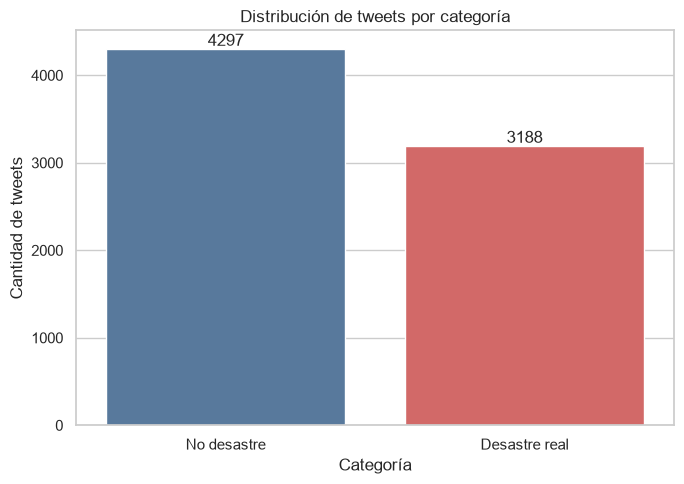

In [12]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_clean,
    x="target",
    hue="target",
    palette={0: "#4C78A8", 1: "#E45756"},
    legend=False
)

ax.set_title("Distribución de tweets por categoría")
ax.set_xlabel("Categoría")
ax.set_ylabel("Cantidad de tweets")
ax.set_xticks([0, 1])
ax.set_xticklabels(["No desastre", "Desastre real"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Distribución de la variable objetivo

Después del tratamiento de textos repetidos y contradictorios, el conjunto de datos contiene 7,485 tweets. De ellos, 4,297, equivalentes al 57.41 %, no corresponden a desastres reales. Los 3,188 registros restantes, equivalentes al 42.59 %, sí están relacionados con desastres reales.

La categoría de tweets que no representan desastres es la más frecuente. Sin embargo, la diferencia entre ambas categorías no constituye un desbalance extremo. Para mantener esta proporción en los conjuntos utilizados por el modelo, posteriormente se realizará una división estratificada entre entrenamiento y prueba.

Además del accuracy, se utilizarán precision, recall y F1-score para evaluar el modelo, debido a que estas métricas permiten analizar su comportamiento en cada categoría.

In [13]:
df_clean["character_count"] = (
    df_clean["text"]
    .astype(str)
    .str.len()
)

df_clean["word_count"] = (
    df_clean["text"]
    .astype(str)
    .str.split()
    .str.len()
)

display(
    df_clean[
        ["text", "character_count", "word_count", "target"]
    ].head()
)

,text,character_count,word_count,target
0,Our Deeds are the Reason of this #earthquake M...,69,13,1
1,Forest fire near La Ronge Sask. Canada,38,7,1
2,All residents asked to 'shelter in place' are ...,133,22,1
3,"13,000 people receive #wildfires evacuation or...",65,8,1
4,Just got sent this photo from Ruby #Alaska as ...,88,16,1


In [14]:
length_summary = (
    df_clean
    .groupby("target")
    .agg(
        tweets=("text", "count"),
        media_caracteres=("character_count", "mean"),
        mediana_caracteres=("character_count", "median"),
        minimo_caracteres=("character_count", "min"),
        maximo_caracteres=("character_count", "max"),
        media_palabras=("word_count", "mean"),
        mediana_palabras=("word_count", "median"),
        minimo_palabras=("word_count", "min"),
        maximo_palabras=("word_count", "max")
    )
    .round(2)
    .reset_index()
)

length_summary["categoría"] = length_summary["target"].map({
    0: "No desastre",
    1: "Desastre real"
})

display(length_summary)

,target,tweets,media_caracteres,mediana_caracteres,minimo_caracteres,maximo_caracteres,media_palabras,mediana_palabras,minimo_palabras,maximo_palabras,categoría
0,0,4297,95.58,101.0,7,157,14.67,15.0,1,31,No desastre
1,1,3188,108.02,114.0,14,151,15.14,15.0,2,30,Desastre real


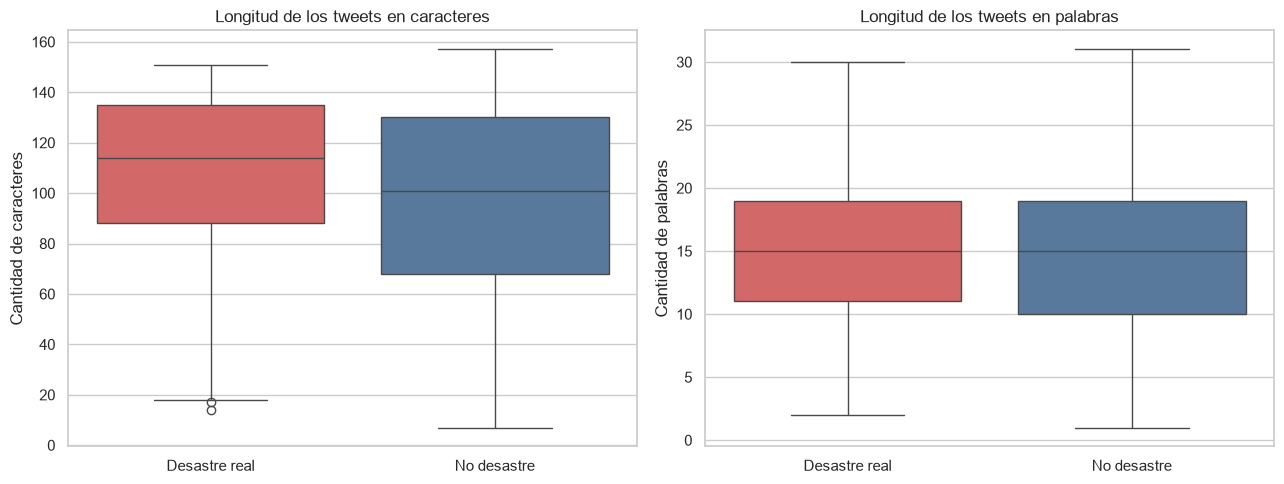

In [15]:
plot_df = df_clean.copy()

plot_df["categoría"] = plot_df["target"].map({
    0: "No desastre",
    1: "Desastre real"
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=plot_df,
    x="categoría",
    y="character_count",
    hue="categoría",
    palette={
        "No desastre": "#4C78A8",
        "Desastre real": "#E45756"
    },
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Longitud de los tweets en caracteres")
axes[0].set_xlabel("")
axes[0].set_ylabel("Cantidad de caracteres")

sns.boxplot(
    data=plot_df,
    x="categoría",
    y="word_count",
    hue="categoría",
    palette={
        "No desastre": "#4C78A8",
        "Desastre real": "#E45756"
    },
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Longitud de los tweets en palabras")
axes[1].set_xlabel("")
axes[1].set_ylabel("Cantidad de palabras")

plt.tight_layout()
plt.show()

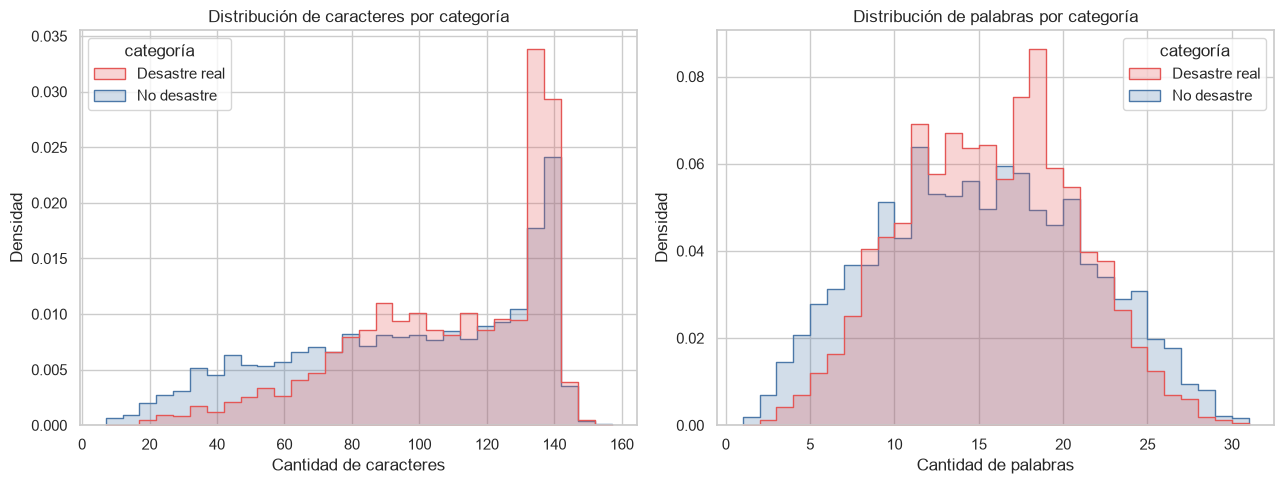

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    data=plot_df,
    x="character_count",
    hue="categoría",
    bins=30,
    element="step",
    stat="density",
    common_norm=False,
    palette={
        "No desastre": "#4C78A8",
        "Desastre real": "#E45756"
    },
    ax=axes[0]
)

axes[0].set_title("Distribución de caracteres por categoría")
axes[0].set_xlabel("Cantidad de caracteres")
axes[0].set_ylabel("Densidad")

sns.histplot(
    data=plot_df,
    x="word_count",
    hue="categoría",
    bins=30,
    element="step",
    stat="density",
    common_norm=False,
    palette={
        "No desastre": "#4C78A8",
        "Desastre real": "#E45756"
    },
    ax=axes[1]
)

axes[1].set_title("Distribución de palabras por categoría")
axes[1].set_xlabel("Cantidad de palabras")
axes[1].set_ylabel("Densidad")

plt.tight_layout()
plt.show()

### Longitud de los tweets

Los tweets relacionados con desastres reales presentan una longitud media de 108.02 caracteres y una mediana de 114 caracteres. En cambio, los tweets que no corresponden a desastres tienen una media de 95.58 caracteres y una mediana de 101 caracteres. Por lo tanto, los tweets sobre desastres tienden a ser más extensos en cantidad de caracteres.

La diferencia en cantidad de palabras es menor. Los tweets sobre desastres contienen en promedio 15.14 palabras, mientras que los tweets que no representan desastres contienen 14.67. Ambas categorías presentan una mediana de 15 palabras.

Los histogramas muestran un solapamiento considerable entre las categorías, especialmente en la cantidad de palabras. Esto indica que la longitud por sí sola no permitiría clasificar correctamente los tweets. Sin embargo, la mayor cantidad de caracteres observada en los tweets sobre desastres puede considerarse una característica potencialmente informativa.

La diferencia entre caracteres y palabras también puede deberse a la presencia de palabras más largas, hashtags, enlaces y detalles específicos en los tweets relacionados con desastres.

## Limpieza y preprocesamiento del texto

Los tweets contienen elementos que pueden generar ruido, como URLs, menciones, signos de puntuación, caracteres especiales y palabras de uso muy frecuente. Por esta razón, se creó una función de preprocesamiento que normaliza los textos antes de calcular frecuencias y entrenar el modelo.

Las actividades realizadas fueron:

1. Conversión del texto a minúsculas.
2. Conversión de entidades HTML, por ejemplo `&amp;`.
3. Eliminación de URLs.
4. Eliminación de menciones de usuarios.
5. Eliminación del símbolo `#`, conservando la palabra del hashtag.
6. Eliminación de apóstrofes, puntuación, emoticonos y caracteres especiales.
7. Eliminación de stopwords en inglés.
8. Conservación de las negaciones `no`, `not` y `nor`.
9. Normalización de espacios.
10. Conservación de números, debido a que cantidades, fechas o expresiones como `911` podrían aportar información sobre emergencias.

No se aplicó stemming ni lematización en esta etapa, con el propósito de conservar palabras interpretables para el análisis de frecuencias y las nubes de palabras.

In [70]:
# Conservar negaciones porque pueden modificar el significado
stop_words_model = stop_words - {"no", "not", "nor"}

def clean_text(text):
    text = str(text)

    # Convertir entidades como &amp; en su símbolo correspondiente
    text = html.unescape(text)

    # Convertir a minúsculas
    text = text.lower()

    # Eliminar URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Eliminar menciones
    text = re.sub(r"@\w+", " ", text)

    # Quitar el símbolo del hashtag, conservando la palabra
    text = text.replace("#", "")

    # Quitar apóstrofes
    text = text.replace("'", "")
    text = text.replace("’", "")

    # Conservar letras, números y espacios
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Normalizar espacios
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenizar y eliminar stopwords
    tokens = text.split()
    tokens = [
        token
        for token in tokens
        if token not in stop_words_model
    ]

    return " ".join(tokens)

In [71]:
import html

# Conservar las negaciones porque modifican el significado
stop_words_model = (
    stop_words - {"no", "not", "nor"}
) | {"amp"}

def clean_text(text):
    text = str(text)

    text = re.sub(r"&amp;?", " and ", text, flags=re.IGNORECASE)
    # Convertir entidades HTML, por ejemplo &amp;
    text = html.unescape(text)

    # Convertir a minúsculas
    text = text.lower()

    # Eliminar URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Eliminar menciones
    text = re.sub(r"@\w+", " ", text)

    # Quitar #, conservando la palabra del hashtag
    text = text.replace("#", "")

    # Quitar apóstrofes
    text = text.replace("'", "")
    text = text.replace("’", "")

    # Conservar letras, números y espacios
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Normalizar espacios
    text = re.sub(r"\s+", " ", text).strip()

    # Eliminar stopwords
    tokens = text.split()
    tokens = [
        token
        for token in tokens
        if token not in stop_words_model
    ]

    return " ".join(tokens)

print("Función clean_text definida correctamente.")

test_tweet = "@News The road is NOT safe! Call 911. #earthquake https://t.co/example"

print("Original:")
print(test_tweet)

print("\nLimpio:")
print(clean_text(test_tweet))

Función clean_text definida correctamente.
Original:
@News The road is NOT safe! Call 911. #earthquake https://t.co/example

Limpio:
road not safe call 911 earthquake


In [72]:
df_clean["clean_text"] = df_clean["text"].apply(clean_text)

print("Limpieza aplicada correctamente.")
print("Dimensiones:", df_clean.shape)

Limpieza aplicada correctamente.
Dimensiones: (7485, 8)


In [73]:
validation_examples = [
    "@News The road is NOT safe! Call 911. #earthquake https://t.co/example",
    "More information at www.example.com about the #flood",
    "Fire &amp; smoke reported near the building!",
    "I am not worried about this at all :)"
]

for example in validation_examples:
    print("Original:", example)
    print("Limpio:  ", clean_text(example))
    print("-" * 80)

Original: @News The road is NOT safe! Call 911. #earthquake https://t.co/example
Limpio:   road not safe call 911 earthquake
--------------------------------------------------------------------------------
Original: More information at www.example.com about the #flood
Limpio:   information flood
--------------------------------------------------------------------------------
Original: Fire &amp; smoke reported near the building!
Limpio:   fire smoke reported near building
--------------------------------------------------------------------------------
Original: I am not worried about this at all :)
Limpio:   not worried
--------------------------------------------------------------------------------


In [74]:
comparison = (
    df_clean[
        ["text", "clean_text", "target"]
    ]
    .sample(10, random_state=42)
)

pd.set_option("display.max_colwidth", 150)
display(comparison)

,text,clean_text,target
2826,BLOG: Rain much needed as drought conditions worsen: Right now Charlotte and much of the surrounding area haveÛ_ http://t.co/OLzaVTJFKH,blog rain much needed drought conditions worsen right charlotte much surrounding area,1
6956,Ancient Mayan Tablet with Hieroglyphics Honors Lowly King http://t.co/Im6m4XAeN2,ancient mayan tablet hieroglyphics honors lowly king,0
3014,There has not been 1 real tear out of #Shelli 's eyes this entire episode. #bb17,not 1 real tear shelli eyes entire episode bb17,0
6569,Ebay Snipe RT? http://t.co/SlQnph34Nt Lego Power Miners Set 8960 Thunder Driller Boxed. ?Please Favorite &amp; Share,ebay snipe rt lego power miners set 8960 thunder driller boxed please favorite share,0
4606,#Flashflood causes #landslide in Gilgit #Pakistan Damage to 20 homes farmland roads and bridges #365disasters http://t.co/911F3IXRH0,flashflood causes landslide gilgit pakistan damage 20 homes farmland roads bridges 365disasters,1
4355,@pmarca content is held hostage by network due to affiliation fees.,content held hostage network due affiliation fees,1
6813,The worst voice I can ever hear is the 'Nikki your in trouble' voice from my mom,worst voice ever hear nikki trouble voice mom,0
468,illegal alien released by Obama/DHS 4 times Charged With Rape &amp; Murder of Santa Maria CA Woman Had Prior Offenses http://t.co/MqP4hF9GpO,illegal alien released obama dhs 4 times charged rape murder santa maria ca woman prior offenses,1
3127,#EMERGENCY in Odai Bucharest Romania 600 Dogs Dying!They are so Hungry that they EAT EACH OTHER! http://t.co/pjigXPVPl0,emergency odai bucharest romania 600 dogs dying hungry eat,1
1295,RT @HuffPostComedy: We should build a wall that keeps Burning Man attendees from coming home http://t.co/xwVW1sft4I http://t.co/j7HUKhWmal,rt build wall keeps burning man attendees coming home,0


In [75]:
empty_clean_texts = (
    df_clean["clean_text"].str.strip().eq("").sum()
)

duplicated_clean_texts = (
    df_clean["clean_text"].duplicated().sum()
)

print("Textos vacíos después de limpiar:", empty_clean_texts)
print(
    "Repeticiones exactas después de limpiar:",
    duplicated_clean_texts
)

print("Ejemplos de textos que quedaron vacíos:")

display(
    df_clean.loc[
        df_clean["clean_text"].str.strip().eq(""),
        ["text", "clean_text", "target"]
    ]
)

print("Ejemplos de repeticiones producidas por la limpieza:")

display(
    df_clean.loc[
        df_clean.duplicated("clean_text", keep=False),
        ["text", "clean_text", "target"]
    ]
    .sort_values("clean_text")
    .head(20)
)

Textos vacíos después de limpiar: 0
Repeticiones exactas después de limpiar: 680
Ejemplos de textos que quedaron vacíos:


,text,clean_text,target


Ejemplos de repeticiones producidas por la limpieza:


,text,clean_text,target
4239,0-day bug in fully patched OS X comes under active exploit to bypass password ... - Ars Technica http://t.co/F7OgzrNPfv,0 day bug fully patched os x comes active exploit bypass password ars technica,0
4252,0-day bug in fully patched OS X comes under active exploit to bypass password ... - Ars Technica http://t.co/53P4oOO1XN,0 day bug fully patched os x comes active exploit bypass password ars technica,0
3849,100 1' MIX NEW FLAT DOUBLE SIDED LINERLESS BOTTLE CAPS YOU CHOOSE MIX FLATTENED - Full reÛ_ http://t.co/wRNpywyaLj http://t.co/Qv7IYdoVx9,100 1 mix new flat double sided linerless bottle caps choose mix flattened full,0
3846,100 1' MIX NEW FLAT DOUBLE SIDED LINERLESS BOTTLE CAPS YOU CHOOSE MIX FLATTENED - Full reÛ_ http://t.co/w00kjPrfdR http://t.co/mIXl1pFRJe,100 1 mix new flat double sided linerless bottle caps choose mix flattened full,0
3862,12' 72W CREE LED Work Light Bar Alloy Spot Flood Combo Diving Offroad 4WD Boat - Full readÛ_ http://t.co/XWN7rgVkzC http://t.co/SWPDQ84boI,12 72w cree led work light bar alloy spot flood combo diving offroad 4wd boat full read,0
3884,12' 72W CREE LED Work Light Bar Alloy Spot Flood Combo Diving Offroad 4WD Boat - Full readÛ_ http://t.co/MJMwA72ER6 http://t.co/ADx9iYi246,12 72w cree led work light bar alloy spot flood combo diving offroad 4wd boat full read,0
4901,13 reasons why we love women in the military - lulgzimbestpicts http://t.co/N1tjCt8HMC http://t.co/pYTQM7rVP0,13 reasons love women military lulgzimbestpicts,0
4904,13 reasons why we love women in the military - lulgzimbestpicts http://t.co/IAPvTqxLht http://t.co/WAMKRe6CKD,13 reasons love women military lulgzimbestpicts,0
4905,13 reasons why we love women in the military - lulgzimbestpicts http://t.co/uZ1yiZ7n6m http://t.co/IjwAr15H16,13 reasons love women military lulgzimbestpicts,0
4895,13 reasons why we love women in the military - lulgzimbestpicts http://t.co/XKMLQ99SjY http://t.co/a3RGQuCUgo,13 reasons love women military lulgzimbestpicts,0


In [76]:
clean_duplicate_rows = df_clean[
    df_clean.duplicated(
        subset="clean_text",
        keep=False
    )
].sort_values("clean_text")

clean_targets_per_text = (
    df_clean
    .groupby("clean_text")["target"]
    .nunique()
)

clean_conflicting_texts = clean_targets_per_text[
    clean_targets_per_text > 1
].index

clean_conflicting_rows = df_clean[
    df_clean["clean_text"].isin(clean_conflicting_texts)
].sort_values(["clean_text", "target"])

print(
    "Filas involucradas en repeticiones limpias:",
    len(clean_duplicate_rows)
)

print(
    "Textos limpios distintos que se repiten:",
    clean_duplicate_rows["clean_text"].nunique()
)

print(
    "Textos limpios con etiquetas contradictorias:",
    len(clean_conflicting_texts)
)

print(
    "Filas involucradas en contradicciones:",
    len(clean_conflicting_rows)
)

Filas involucradas en repeticiones limpias: 974
Textos limpios distintos que se repiten: 294
Textos limpios con etiquetas contradictorias: 68
Filas involucradas en contradicciones: 251


In [77]:
display(
    clean_conflicting_rows[
        ["text", "clean_text", "target"]
    ].head(30)
)

clean_duplicate_summary = (
    clean_duplicate_rows
    .groupby("target")
    .size()
    .rename("filas_involucradas")
    .reset_index()
)

clean_duplicate_summary["categoría"] = (
    clean_duplicate_summary["target"].map({
        0: "No desastre",
        1: "Desastre real"
    })
)

display(clean_duplicate_summary)

,text,clean_text,target
3856,2pcs 18W CREE Led Work Light Offroad Lamp Car Truck Boat Mining 4WD FLOOD BEAM - Full reaÛ_ http://t.co/VDeFmulx43 http://t.co/yqpAIjSa5g,2pcs 18w cree led work light offroad lamp car truck boat mining 4wd flood beam full rea,0
3869,2pcs 18W CREE Led Work Light Offroad Lamp Car Truck Boat Mining 4WD FLOOD BEAM - Full reaÛ_ http://t.co/O1SMUh2unn http://t.co/xqj6WgiuQH,2pcs 18w cree led work light offroad lamp car truck boat mining 4wd flood beam full rea,0
3872,2pcs 18W CREE Led Work Light Offroad Lamp Car Truck Boat Mining 4WD FLOOD BEAM - Full reaÛ_ http://t.co/1QT51r5h98 http://t.co/OQH1JbUEnl,2pcs 18w cree led work light offroad lamp car truck boat mining 4wd flood beam full rea,0
3863,2pcs 18W CREE Led Work Light Offroad Lamp Car Truck Boat Mining 4WD FLOOD BEAM - Full reaÛ_ http://t.co/ApWXS5Mm44 http://t.co/DS76loZLSu,2pcs 18w cree led work light offroad lamp car truck boat mining 4wd flood beam full rea,1
5712,#360WiseNews : China's Stock Market Crash: Are There Gems In The Rubble? http://t.co/eaTFro3d5x,360wisenews chinas stock market crash gems rubble,0
5732,#360WiseNews : China's Stock Market Crash: Are There Gems In The Rubble? http://t.co/gQskwqZuUl,360wisenews chinas stock market crash gems rubble,0
5718,#360WiseNews : China's Stock Market Crash: Are There Gems In The Rubble? http://t.co/9Naw3QOQOL,360wisenews chinas stock market crash gems rubble,1
5728,#360WiseNews : China's Stock Market Crash: Are There Gems In The Rubble? http://t.co/aOd2ftBMGU,360wisenews chinas stock market crash gems rubble,1
2788,Angry Woman Openly Accuses NEMA Of Stealing Relief Materials Meant For IDPs: An angry Internally Displaced wom... http://t.co/Khd99oZ7u3,angry woman openly accuses nema stealing relief materials meant idps angry internally displaced wom,0
2805,Angry Woman Openly Accuses NEMA Of Stealing Relief Materials Meant For IDPs: An angry Internally Displaced wom... http://t.co/6ySbCSSzYS,angry woman openly accuses nema stealing relief materials meant idps angry internally displaced wom,0


,target,filas_involucradas,categoría
0,0,389,No desastre
1,1,585,Desastre real


In [78]:
# Eliminar textos limpios con etiquetas contradictorias
df_text = df_clean[
    ~df_clean["clean_text"].isin(clean_conflicting_texts)
].copy()

# Conservar una sola aparición de cada texto limpio consistente
df_text = (
    df_text
    .drop_duplicates(subset="clean_text", keep="first")
    .reset_index(drop=True)
)

print("Dimensiones antes del tratamiento:", df_clean.shape)
print("Dimensiones del dataset textual final:", df_text.shape)
print("Filas eliminadas en esta etapa:", len(df_clean) - len(df_text))

print(
    "Textos limpios vacíos:",
    df_text["clean_text"].str.strip().eq("").sum()
)

print(
    "Textos limpios repetidos:",
    df_text["clean_text"].duplicated().sum()
)

print(
    "Contradicciones restantes:",
    (df_text.groupby("clean_text")["target"].nunique() > 1).sum()
)

Dimensiones antes del tratamiento: (7485, 8)
Dimensiones del dataset textual final: (6737, 8)
Filas eliminadas en esta etapa: 748
Textos limpios vacíos: 0
Textos limpios repetidos: 0
Contradicciones restantes: 0


In [79]:
final_target_summary = (
    df_text["target"]
    .value_counts()
    .sort_index()
    .rename_axis("target")
    .reset_index(name="cantidad")
)

final_target_summary["porcentaje"] = (
    final_target_summary["cantidad"]
    / len(df_text)
    * 100
).round(2)

final_target_summary["categoría"] = (
    final_target_summary["target"].map({
        0: "No desastre",
        1: "Desastre real"
    })
)

display(final_target_summary)

print(
    "Total verificado:",
    final_target_summary["cantidad"].sum()
)

,target,cantidad,porcentaje,categoría
0,0,3999,59.36,No desastre
1,1,2738,40.64,Desastre real


Total verificado: 6737


### Validación posterior al preprocesamiento

Después de aplicar la función de limpieza no se encontraron textos vacíos. Sin embargo, se detectaron 680 repeticiones adicionales en `clean_text`. Al considerar también la primera aparición, 974 filas estaban involucradas en repeticiones y correspondían a 294 textos limpios distintos.

Estas repeticiones aparecieron porque algunos tweets originales se diferenciaban únicamente por URLs, menciones, puntuación u otros elementos eliminados durante el preprocesamiento. También se identificaron 68 textos limpios con etiquetas contradictorias, los cuales involucraban 251 filas.

Se eliminaron todas las apariciones de los textos limpios con etiquetas contradictorias, ya que no era posible determinar objetivamente cuál etiqueta era correcta. Para los textos limpios repetidos con etiquetas consistentes se conservó una sola aparición.

El conjunto de datos textual definitivo contiene 6,737 registros, sin textos vacíos, repeticiones exactas ni etiquetas contradictorias. Esta decisión evita que textos equivalentes aparezcan simultáneamente en entrenamiento y prueba, reduce el riesgo de fuga de información y evita que las repeticiones inflen artificialmente las frecuencias de palabras.

## Análisis de n-gramas

Un n-grama es una secuencia de `n` términos consecutivos. Los unigramas representan palabras individuales, mientras que los bigramas representan pares de palabras consecutivas.

El análisis se realizará por separado para los tweets que representan desastres reales y para los que no representan desastres. Para cada término se calculará:

- **Frecuencia:** cantidad total de apariciones del término.
- **Probabilidad relativa:** frecuencia del término dividida entre la cantidad total de apariciones de todos los términos de la categoría.

Este análisis permitirá identificar palabras y expresiones asociadas con cada clase y estudiar si los bigramas proporcionan más contexto que las palabras individuales.

In [80]:
def calculate_top_ngrams(
    texts,
    ngram_range=(1, 1),
    top_n=20
):
    vectorizer = CountVectorizer(
        ngram_range=ngram_range
    )

    matrix = vectorizer.fit_transform(texts)

    terms = vectorizer.get_feature_names_out()
    frequencies = matrix.sum(axis=0).A1
    total_frequency = frequencies.sum()

    results = pd.DataFrame({
        "ngram": terms,
        "frecuencia": frequencies
    })

    results["probabilidad"] = (
        results["frecuencia"] / total_frequency
    )

    results = (
        results
        .sort_values(
            ["frecuencia", "ngram"],
            ascending=[False, True]
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return results

In [81]:
unigrams_not_disaster = calculate_top_ngrams(
    df_text.loc[
        df_text["target"] == 0,
        "clean_text"
    ],
    ngram_range=(1, 1),
    top_n=20
)

unigrams_disaster = calculate_top_ngrams(
    df_text.loc[
        df_text["target"] == 1,
        "clean_text"
    ],
    ngram_range=(1, 1),
    top_n=20
)

print("Unigramas más frecuentes: no desastre")
display(unigrams_not_disaster)

print("Unigramas más frecuentes: desastre real")
display(unigrams_disaster)

Unigramas más frecuentes: no desastre


,ngram,frecuencia,probabilidad
0,like,245,0.007182
1,im,237,0.006947
2,not,200,0.005863
3,get,162,0.004749
4,no,146,0.004280
5,dont,141,0.004133
6,new,131,0.003840
7,one,129,0.003781
8,body,102,0.002990
9,would,96,0.002814


Unigramas más frecuentes: desastre real


,ngram,frecuencia,probabilidad
0,fire,164,0.006137
1,news,111,0.004153
2,no,102,0.003817
3,police,96,0.003592
4,via,92,0.003442
5,people,90,0.003368
6,like,89,0.003330
7,not,89,0.003330
8,disaster,87,0.003255
9,california,85,0.003181


In [82]:
unigrams_not_disaster_display = (
    unigrams_not_disaster.copy()
)

unigrams_disaster_display = (
    unigrams_disaster.copy()
)

unigrams_not_disaster_display["probabilidad"] = (
    unigrams_not_disaster_display["probabilidad"] * 100
).round(3)

unigrams_disaster_display["probabilidad"] = (
    unigrams_disaster_display["probabilidad"] * 100
).round(3)

unigrams_not_disaster_display = (
    unigrams_not_disaster_display.rename(
        columns={"probabilidad": "probabilidad (%)"}
    )
)

unigrams_disaster_display = (
    unigrams_disaster_display.rename(
        columns={"probabilidad": "probabilidad (%)"}
    )
)

print("Unigramas: no desastre")
display(unigrams_not_disaster_display)

print("Unigramas: desastre real")
display(unigrams_disaster_display)

Unigramas: no desastre


,ngram,frecuencia,probabilidad (%)
0,like,245,0.718
1,im,237,0.695
2,not,200,0.586
3,get,162,0.475
4,no,146,0.428
5,dont,141,0.413
6,new,131,0.384
7,one,129,0.378
8,body,102,0.299
9,would,96,0.281


Unigramas: desastre real


,ngram,frecuencia,probabilidad (%)
0,fire,164,0.614
1,news,111,0.415
2,no,102,0.382
3,police,96,0.359
4,via,92,0.344
5,people,90,0.337
6,like,89,0.333
7,not,89,0.333
8,disaster,87,0.326
9,california,85,0.318


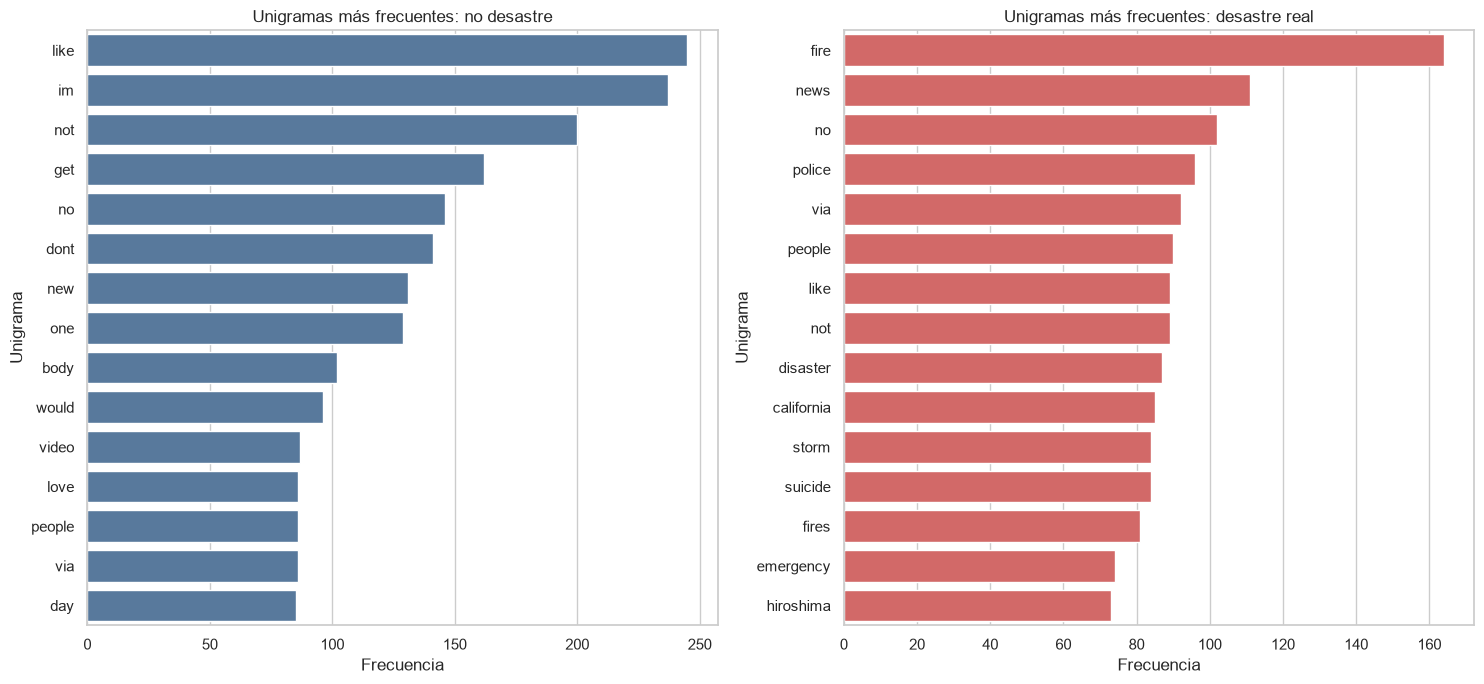

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

sns.barplot(
    data=unigrams_not_disaster.head(15),
    x="frecuencia",
    y="ngram",
    color="#4C78A8",
    ax=axes[0]
)

axes[0].set_title(
    "Unigramas más frecuentes: no desastre"
)
axes[0].set_xlabel("Frecuencia")
axes[0].set_ylabel("Unigrama")

sns.barplot(
    data=unigrams_disaster.head(15),
    x="frecuencia",
    y="ngram",
    color="#E45756",
    ax=axes[1]
)

axes[1].set_title(
    "Unigramas más frecuentes: desastre real"
)
axes[1].set_xlabel("Frecuencia")
axes[1].set_ylabel("Unigrama")

plt.tight_layout()
plt.show()

In [84]:
shared_unigrams = set(
    unigrams_not_disaster["ngram"]
).intersection(
    set(unigrams_disaster["ngram"])
)

print(
    "Unigramas presentes entre los 20 más frecuentes "
    "de ambas categorías:"
)

print(sorted(shared_unigrams))

Unigramas presentes entre los 20 más frecuentes de ambas categorías:
['like', 'no', 'not', 'one', 'people', 'via']


### Análisis de unigramas

Los unigramas muestran diferencias temáticas entre las dos categorías. En los tweets que no representan desastres predominan palabras asociadas con lenguaje cotidiano e informal, como `like`, `im`, `get`, `dont`, `love`, `day` y `know`. La palabra más frecuente fue `like`, con 245 apariciones y una probabilidad relativa aproximada de 0.718 %.

En los tweets relacionados con desastres aparecen términos directamente asociados con emergencias y sucesos graves. Entre ellos se encuentran `fire`, `police`, `disaster`, `storm`, `emergency`, `killed`, `crash`, `fires` y `nuclear`. La palabra más frecuente fue `fire`, con 164 apariciones y una probabilidad relativa aproximada de 0.614 %.

Las palabras `like`, `no`, `not`, `one`, `people` y `via` aparecen entre los 20 unigramas más frecuentes de ambas categorías. Su presencia compartida indica que no necesariamente permiten distinguir las categorías de manera aislada. Por ejemplo, `people` puede utilizarse tanto en una noticia sobre víctimas como en una conversación cotidiana.

La palabra `via` probablemente está relacionada con la forma de compartir noticias o publicaciones y no directamente con un desastre. También aparecen formas como `im`, `dont` y `cant`, producidas al eliminar los apóstrofes de las contracciones. Aunque estos términos podrían normalizarse adicionalmente, se conservaron porque representan diferencias en el estilo de escritura y podrían aportar información al clasificador.

Los resultados sugieren que varios unigramas pueden ayudar a distinguir los tweets sobre desastres. Sin embargo, las palabras individuales no siempre proporcionan suficiente contexto, por lo que es necesario explorar bigramas.

In [85]:
bigrams_not_disaster = calculate_top_ngrams(
    df_text.loc[
        df_text["target"] == 0,
        "clean_text"
    ],
    ngram_range=(2, 2),
    top_n=20
)

bigrams_disaster = calculate_top_ngrams(
    df_text.loc[
        df_text["target"] == 1,
        "clean_text"
    ],
    ngram_range=(2, 2),
    top_n=20
)

print("Bigramas más frecuentes: no desastre")
display(bigrams_not_disaster)

print("Bigramas más frecuentes: desastre real")
display(bigrams_disaster)

Bigramas más frecuentes: no desastre


,ngram,frecuencia,probabilidad
0,liked video,30,0.000996
1,cross body,28,0.000930
2,body bagging,24,0.000797
3,looks like,21,0.000697
4,body bags,20,0.000664
5,burning buildings,19,0.000631
6,loud bang,19,0.000631
7,feel like,17,0.000565
8,first responders,17,0.000565
9,im not,17,0.000565


Bigramas más frecuentes: desastre real


,ngram,frecuencia,probabilidad
0,suicide bomber,36,0.001501
1,suicide bombing,34,0.001417
2,burning buildings,28,0.001167
3,mass murder,26,0.001084
4,severe thunderstorm,26,0.001084
5,wild fires,24,0.001001
6,heat wave,23,0.000959
7,oil spill,23,0.000959
8,70 years,21,0.000875
9,natural disaster,20,0.000834


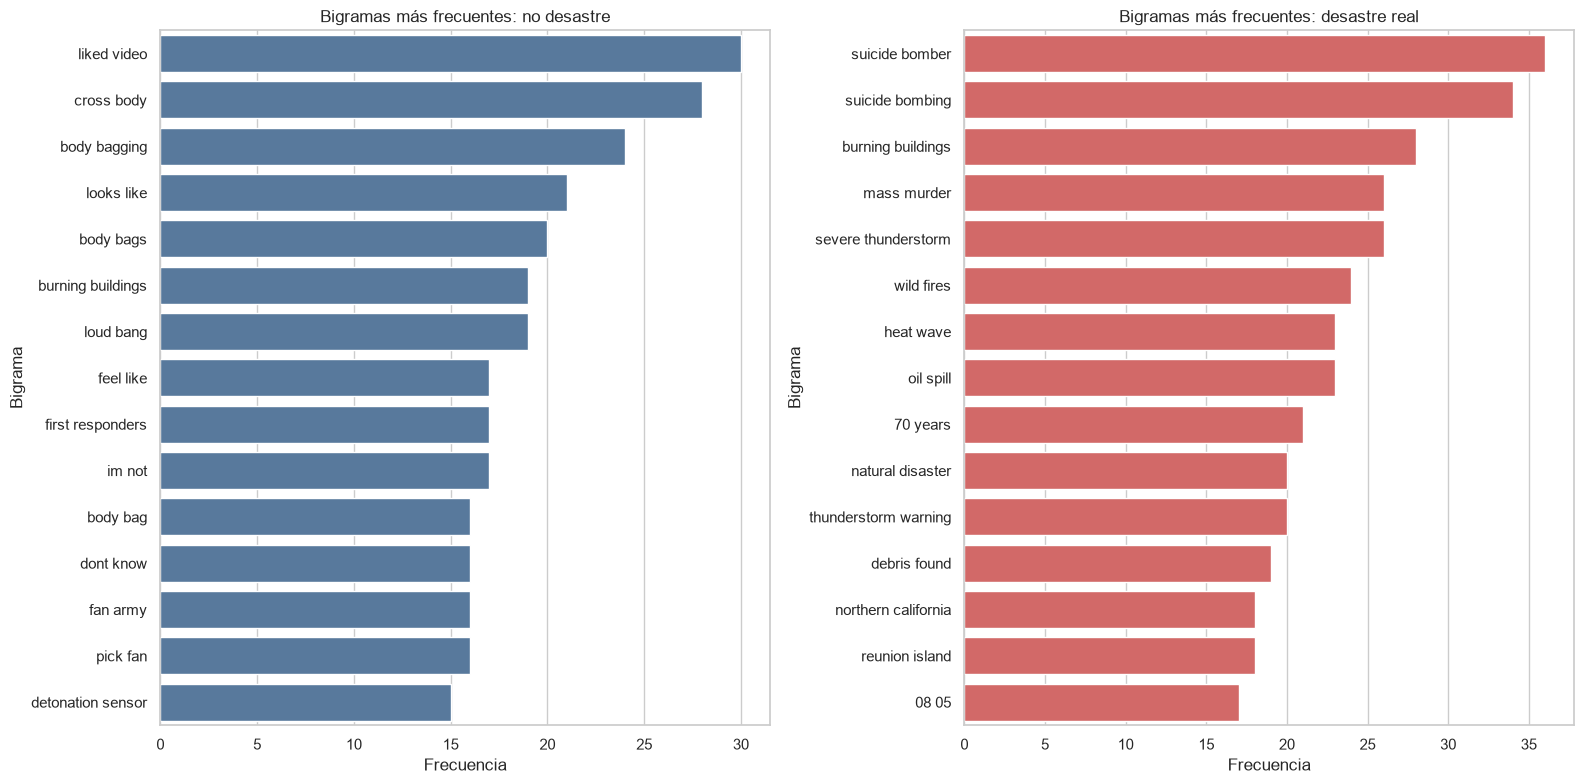

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(
    data=bigrams_not_disaster.head(15),
    x="frecuencia",
    y="ngram",
    color="#4C78A8",
    ax=axes[0]
)

axes[0].set_title(
    "Bigramas más frecuentes: no desastre"
)
axes[0].set_xlabel("Frecuencia")
axes[0].set_ylabel("Bigrama")

sns.barplot(
    data=bigrams_disaster.head(15),
    x="frecuencia",
    y="ngram",
    color="#E45756",
    ax=axes[1]
)

axes[1].set_title(
    "Bigramas más frecuentes: desastre real"
)
axes[1].set_xlabel("Frecuencia")
axes[1].set_ylabel("Bigrama")

plt.tight_layout()
plt.show()

In [87]:
shared_bigrams = set(
    bigrams_not_disaster["ngram"]
).intersection(
    set(bigrams_disaster["ngram"])
)

print(
    "Bigramas presentes entre los 20 más frecuentes "
    "de ambas categorías:"
)

print(sorted(shared_bigrams))

Bigramas presentes entre los 20 más frecuentes de ambas categorías:
['burning buildings']


### Análisis de bigramas

Los bigramas proporcionan más contexto que las palabras individuales. En los tweets clasificados como desastres reales aparecen expresiones directamente relacionadas con emergencias, como `suicide bomber`, `suicide bombing`, `severe thunderstorm`, `wild fires`, `heat wave`, `oil spill`, `natural disaster`, `thunderstorm warning`, `debris found` y `nuclear disaster`.

El bigrama más frecuente de esta categoría fue `suicide bomber`, con 36 apariciones y una probabilidad relativa aproximada de 0.150 %. Le siguió `suicide bombing`, con 34 apariciones. Estas combinaciones contienen más información que los unigramas `suicide` o `fire`, porque permiten identificar con mayor precisión el tipo de evento mencionado.

En los tweets que no representan desastres aparecen combinaciones asociadas con lenguaje cotidiano, como `liked video`, `looks like`, `feel like`, `im not` y `dont know`. No obstante, también se observaron expresiones relacionadas aparentemente con emergencias, como `body bags`, `first responders`, `war zone`, `detonation sensor` y `burning buildings`.

La presencia de expresiones relacionadas con emergencias en la categoría de no desastre evidencia la ambigüedad del lenguaje. Estos términos pueden emplearse de manera figurada, humorística, hipotética o dentro de conversaciones que no reportan un suceso real.

`burning buildings` fue el único bigrama presente entre los 20 más frecuentes de ambas categorías. En los tweets de desastre apareció 28 veces, mientras que en los tweets de no desastre apareció 19 veces. Por tanto, este bigrama no permite identificar por sí solo la categoría y necesita ser interpretado junto con el resto del tweet.

Los resultados justifican incorporar unigramas y bigramas en el modelo. Los unigramas proporcionan cobertura de vocabulario, mientras que los bigramas capturan expresiones con mayor contexto.s

### Conclusión del análisis de n-gramas

Los unigramas permiten identificar vocabulario relacionado con cada categoría. Palabras como `fire`, `police`, `disaster`, `storm`, `emergency`, `killed` y `crash` presentan una relación clara con los tweets sobre desastres. En cambio, palabras como `like`, `im`, `get`, `love` y `know` reflejan un lenguaje más cotidiano y aparecen con mayor frecuencia en los tweets que no corresponden a desastres.

No obstante, algunos términos aparecen en ambas categorías y una palabra relacionada con emergencias no garantiza que el tweet describa un desastre real. Por esta razón, se exploraron bigramas.

Los bigramas proporcionan mayor contexto mediante expresiones como `suicide bomber`, `severe thunderstorm`, `wild fires`, `heat wave`, `oil spill` y `nuclear disaster`. Estas combinaciones son más específicas que las palabras individuales y pueden facilitar la clasificación.

También se identificaron expresiones relacionadas con emergencias dentro de la categoría de no desastre. Esto demuestra que el problema contiene ambigüedad y que el modelo debe considerar múltiples términos del tweet.

Por estas razones, el modelo preliminar utilizará una representación que combine unigramas y bigramas mediante `ngram_range=(1, 2)`. No se analizarán trigramas en este avance, ya que los requisitos se concentran en unigramas y bigramas.